<a href="https://colab.research.google.com/github/JuliaZyrianova/imdb-movies-eda/blob/main/%22%D0%A0%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_(EDA)%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://adabul.com/wp-content/uploads/2020/04/diziler-360x240.jpg)

## 1. Описание датасета и задания

Представлен датасет с данными о 5000 фильмах, имеющих наибольший рейтинг на сайте IMDb (датасет выложен на платформе [Kaggle](https://www.kaggle.com/datasets/totoro29/imdb-movies)).

***Информация, содержащаяся в датасете:***
1.   Ссылка на постер фильма (poster).
2.   Наименование фильма (title).
3.   Класс фильма по рейтингу the British Board of Film Classification (BBFC) (certificate).
4.   Продолжительность фильма (runtime).
5.   Жанр фильма (genre).
6.   Рейтинг фильма на платформе IMBD (rating).
7.   Описание сюжета фильма (about).
8.   Кинорежиссер фильма (director).
9.   Актеры-звезды фильма (stars).
10.  Количество проголосовавших за фильм (votes).
11.  Доход с фильма (gross_earn).

**Задача** — провести разведочный анализ данных, найти взаимосвязи и сформулировать выводы.

1.   Выполнить неграфический и графический анализ количественных признаков.
2.   Выполнить неграфический и графический анализ категориальных признаков.
3.   Выполнить анализ взаимосвязи двух количественных признаков.
4.   Выполнить анализ взаимосвязи двух категориальных признаков.
5.   Выполнить анализ взаимосвязи количественного и категориального признаков.

## 2. Загрузка датасета

In [ ]:
from google.colab import files

In [ ]:
files.upload()

In [ ]:
import pandas as pd

In [ ]:
dataset= pd.read_csv('movies_clean.csv')

In [ ]:
dataset.head()

,Unnamed: 0,poster,title,certificate,runtime,genre,rating,about,director,stars,votes,gross_earn,runtime_clear,gross_earn_clear
0,0,https://m.media-amazon.com/images/S/sash/4Fyxw...,The Shawshank Redemption,15,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,Frank Darabont,"('Tim Robbins',), ('Morgan Freeman',), ('Bob G...","26,26,905",$28.34M,142,28.34
1,1,https://m.media-amazon.com/images/S/sash/4Fyxw...,Hababam Sinifi,12A,87 min,"Comedy, Drama",9.2,"Lazy, uneducated students share a very close b...",Ertem Egilmez,"('Kemal Sunal',), ('Münir Özkul',), ('Halit Ak...","40,492",NaN,87,NaN
2,2,https://m.media-amazon.com/images/S/sash/4Fyxw...,The Godfather,X,175 min,"Crime, Drama",9.2,The aging patriarch of an organized crime dyna...,Francis Ford Coppola,"('Marlon Brando',), ('Al Pacino',), ('James Ca...","18,19,641",$134.97M,175,134.97
3,3,https://m.media-amazon.com/images/S/sash/4Fyxw...,The Godfather: Part II,X,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,Francis Ford Coppola,"('Al Pacino',), ('Robert De Niro',), ('Robert ...","12,49,182",$57.30M,202,57.30
4,4,https://m.media-amazon.com/images/S/sash/4Fyxw...,Schindler's List,15,195 min,"Biography, Drama, History",9.0,"In German-occupied Poland during World War II,...",Steven Spielberg,"('Liam Neeson',), ('Ralph Fiennes',), ('Ben Ki...","13,33,407",$96.90M,195,96.90


Удалим столбец 'Unnamed: 0' как ненужный

In [ ]:
dataset.drop(columns='Unnamed: 0', inplace=True)

## 4. Оценка размеров датасета, выбор признаков для анализа

In [ ]:
dataset.shape

(4970, 13)

Признаки - 13

Записи - 4970

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4970 entries, 0 to 4969
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   poster            4970 non-null   object 
 1   title             4970 non-null   object 
 2   certificate       4970 non-null   object 
 3   runtime           4970 non-null   object 
 4   genre             4970 non-null   object 
 5   rating            4970 non-null   float64
 6   about             4956 non-null   object 
 7   director          4970 non-null   object 
 8   stars             4970 non-null   object 
 9   votes             4970 non-null   object 
 10  gross_earn        4574 non-null   object 
 11  runtime_clear     4970 non-null   int64  
 12  gross_earn_clear  4574 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 504.9+ KB


Пропущенные значения по признакам:

about

gross_earn и соответственно gross_earn_clear



**Признаки, которые будут использованы для дальнейшего анализа:**

***Количественные признаки:***
1.   Продолжительность фильма: runtime_clear
2.   Доход с фильма: gross_earn_clear

***Категориальные признаки:***
1.   Наименование фильма: title
2.   Класс фильма: certificate
3.   Жанр фильма: genre
4.   Рейтинг фильма: rating
5.   Кинорежиссер: director
6.   Актеры-звезды фильма: stars


## 5. Неграфический и графический анализ количественных признаков

### *5.1. gross_earn_clear* ДОХОД

In [ ]:
gross_earn = dataset['gross_earn_clear']

In [ ]:
max_value = gross_earn.max()
min_value =gross_earn.min()
print('Наибольший доход: ', max_value, 'Наименьший доход: ', min_value)

Наибольший доход:  936.66 Наименьший доход:  0.0




```
# Выбран кодовый формат
```

Рассмотрим наблюдения, у которых значение по признаку gross_earn равно 0.0

In [ ]:
dataset[dataset['gross_earn_clear']==0.0]

,poster,title,certificate,runtime,genre,rating,about,director,stars,votes,gross_earn,runtime_clear,gross_earn_clear
540,https://m.media-amazon.com/images/S/sash/4Fyxw...,Mr. Nobody,15,141 min,"Drama, Fantasy, Romance",7.8,A boy stands on a station platform as a train ...,Jaco Van Dormael,"('Jared Leto',), ('Sarah Polley',), ('Diane Kr...","2,32,030",$0.00M,141,0.0
736,https://m.media-amazon.com/images/S/sash/4Fyxw...,Adam's Apples,R,94 min,"Comedy, Crime, Drama",7.7,A neo-Nazi sentenced to community service at a...,Anders Thomas Jensen,"('Ulrich Thomsen',), ('Mads Mikkelsen',), ('Ni...","50,694",$0.00M,94,0.0
1381,https://m.media-amazon.com/images/S/sash/4Fyxw...,Pusher,18,110 min,"Crime, Thriller",7.3,A drug pusher grows increasingly desperate aft...,Nicolas Winding Refn,"('Kim Bodnia',), ('Zlatko Buric',), ('Laura Dr...","39,929",$0.00M,110,0.0
1453,https://m.media-amazon.com/images/S/sash/4Fyxw...,Ben X,15,93 min,"Drama, Thriller",7.3,As an alternative to getting bullied at school...,Nic Balthazar,"('Marijke Pinoy',), ('Greg Timmermans',), ('Ce...","18,943",$0.00M,93,0.0
1567,https://m.media-amazon.com/images/S/sash/4Fyxw...,Nothing But the Truth,15,108 min,"Crime, Drama",7.2,"In Washington, D.C., a reporter faces a possib...",Rod Lurie,"('Kate Beckinsale',), ('Matt Dillon',), ('Vera...","38,253",$0.00M,108,0.0
2120,https://m.media-amazon.com/images/S/sash/4Fyxw...,Perfect Sense,15,92 min,"Drama, Romance, Sci-Fi",7.0,A chef and a scientist fall in love as an epid...,David Mackenzie,"('Ewan McGregor',), ('Eva Green',), ('Lauren T...","60,249",$0.00M,92,0.0
2364,https://m.media-amazon.com/images/S/sash/4Fyxw...,Ginger Snaps,18,108 min,"Drama, Fantasy, Horror",6.8,"Two death-obsessed sisters, outcasts in their ...",John Fawcett,"('Emily Perkins',), ('Katharine Isabelle',), (...","47,082",$0.00M,108,0.0
3153,https://m.media-amazon.com/images/S/sash/4Fyxw...,Son of a Gun,15,108 min,"Action, Crime, Drama",6.4,"JR busts out of prison with Brendan Lynch, Aus...",Julius Avery,"('Ewan McGregor',), ('Brenton Thwaites',), ('A...","28,121",$0.00M,108,0.0
3332,https://m.media-amazon.com/images/S/sash/4Fyxw...,Flypaper,15,87 min,"Comedy, Crime, Mystery",6.3,A man caught in the middle of two simultaneous...,Rob Minkoff,"('Patrick Dempsey',), ('Ashley Judd',), ('Tim ...","33,003",$0.00M,87,0.0
3638,https://m.media-amazon.com/images/S/sash/4Fyxw...,Chalet Girl,12A,97 min,"Comedy, Romance, Sport",6.2,Former skateboard champion Kim wants to make m...,Phil Traill,"('Felicity Jones',), ('Ed Westwick',), ('Bill ...","25,470",$0.00M,97,0.0


Таких значений не так много. Можно их исключить из анализа

In [ ]:
gross_earn = dataset[dataset['gross_earn_clear']!=0.0]['gross_earn_clear']

In [ ]:
max_value = gross_earn.max()
min_value = gross_earn.min()
print('Наибольший доход: ', max_value, 'Наименьший доход: ', min_value)

Наибольший доход:  936.66 Наименьший доход:  0.01


Среднее

In [ ]:
mean_value =gross_earn.mean()
print('Средний доход с фильма: ', mean_value)

Средний доход с фильма:  49.07882623957876


Медиана

In [ ]:
median_value = gross_earn.median()
print('Медиана доходов фильмов: ', median_value)

Медиана доходов фильмов:  28.345


Процентили

In [ ]:
percentile_10_value = gross_earn.quantile(0.10)
percentile_25_value = gross_earn.quantile(0.25)
percentile_50_value = gross_earn.quantile(0.50)
percentile_75_value = gross_earn.quantile(0.75)
percentile_90_value = gross_earn.quantile(0.90)
print('10-й процентиль доходов фильмов: ', percentile_10_value)
print('25-й процентиль доходов фильмов: ', percentile_25_value)
print('50-й процентиль доходов фильмов: ', percentile_50_value)
print('75-й процентиль доходов фильмов: ', percentile_75_value)
print('90-й процентиль доходов фильмов: ', percentile_90_value)

10-й процентиль доходов фильмов:  0.7970000000000005
25-й процентиль доходов фильмов:  7.0
50-й процентиль доходов фильмов:  28.345
75-й процентиль доходов фильмов:  63.04
90-й процентиль доходов фильмов:  121.96800000000002


In [ ]:
gross_earn.describe()

,gross_earn_clear
count,4558.000000
mean,49.078826
std,67.171717
min,0.010000
25%,7.000000
50%,28.345000
75%,63.040000
max,936.660000


In [ ]:
import matplotlib.pyplot as plt

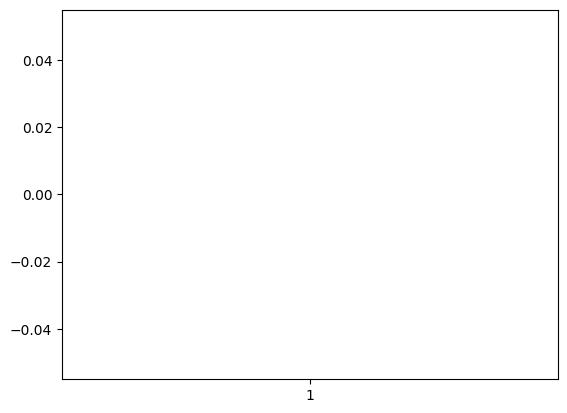

In [ ]:
plt.boxplot(gross_earn)
plt.show()

Диаграмма пустая.  Это связано с наличием пропущенных значений по признаку.

In [ ]:
gross_earn_without_na =gross_earn.dropna()
gross_earn_without_na

,gross_earn_clear
0,28.34
2,134.97
3,57.30
4,96.90
5,4.36
...,...
4965,10.25
4966,14.19
4967,0.03
4968,4.92


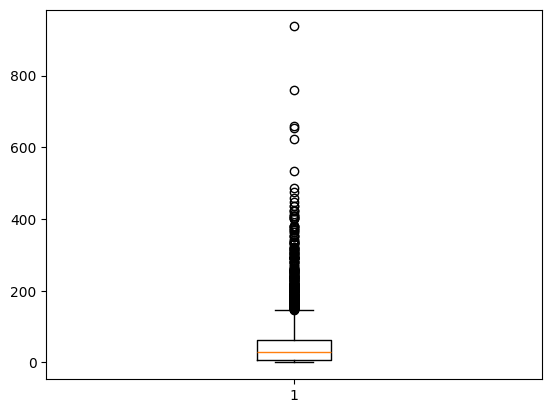

In [ ]:
plt.boxplot(gross_earn_without_na)
plt.show()

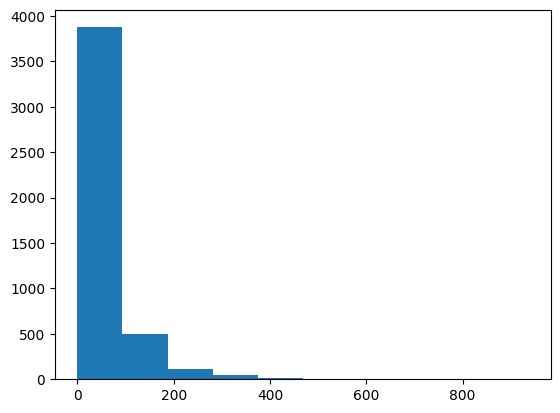

In [ ]:
plt.hist(gross_earn)
plt.show()

Гистограмма показывает, достаточно большой размах в данных, что подтверждается и показателями описательной статистики (min и max). Ограничим графический анализ 10 процентилем снизу и 90 процентилем сверху, тем самым обработав часть выбросов

In [ ]:
gross_earn_2 = dataset[
    (dataset['gross_earn_clear']>=percentile_10_value)&
    (dataset['gross_earn_clear']<=percentile_90_value)]['gross_earn_clear']

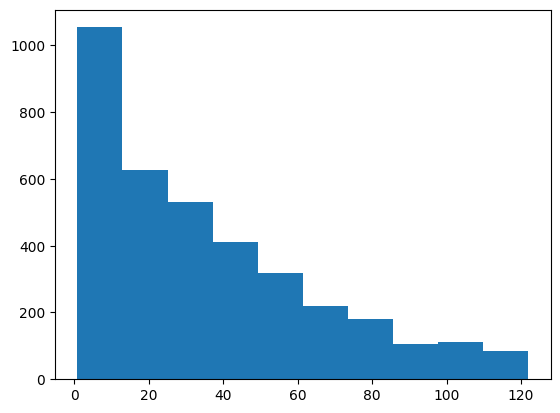

In [ ]:
plt.hist(gross_earn_2)
plt.show()

**Выводы:**

1. max=936.66, min=0.01. Мы видим сильный размах значений между минимумом и максимумом дохода от фильмов.
2. На мой взгляд, в контексте доходов фильмов, строго нулевой доход является крайне маловероятным и аномальным событием. Фильм, выпущенный для проката, практически всегда гарантирует хоть какой-то доход. Наличие нулевых значений может исказить анализ, даже если таких записей не много, они влияют на среднее и другие статистические показатели -> сильно смещают их вниз, поэтому удаление оправдано. Если таких значений много и нули являются результатом каких-либо особенностей сбора данных, то нужно учитывать эту особенность (предобработкой).
3. mean = 49.079, median = 28.345 - среднее значение значительно выше медианы. Это говорит о том, что есть фильмы с очень высокими доходами, т.к. среднее значение сильно подвержено влиянию фильмов с такими доходами.
4.  1. **10-й процентиль**: 10% фильмов имеют доход не более 0.797.
    2. **25-й процентиль**: 25% значений не превышают 7. Это говорит о том, что уровень дохода от четверти фильмов сравнительно низкий.
    3. **50-й процентиль (медиана)**: 50% фильмов имеют доход не более 28.345.
    4. **75-й процентиль**: 75% значений не превышают 63.04. Большая часть данных лежит в диапазоне от 0 до 63.
    5. **90-й процентиль**: 90% фильмов имеют доход не более 121.968. Это подтверждает, что лишь небольшая часть фильмов приносит значительно более высокий доход, чем большинство.
5. **Графический анализ**:

  **Ящик с усами (box plot):**

  Мы видим большое количество фильмов с низкими доходами в нижней части и выбросы в верхней с высокими доходами.

  **Гистограмма (hist):**
  Рассматривая 10-й и 90-й процентили: 80% фильмов имеет доход в диапазоне от 8 до 122.
  Гистограмма также как и "ящик с усами" показывает, что большинство фильмов имеют относительно низкие доходы, и количество снижается по мере роста дохода.

6. **Выбросы** являются частью данных о доходах фильмов. Решение об их исключении зависит от целей исследования.


На мой взгляд, наличие большого количества фильмов со средними и низкими доходами и небольшого числа "блокбастеров" с очень высокими доходами является естественной структурой рынка кинопроката.


## 6. Неграфический и графический анализ категориальных признаков

### *6.1. certificate*

Описание классификации [the British Board of Film Classification (BBFC)]( https://www.bbfc.co.uk/about-classification/classification-guidelines)

Описательные статистики

In [ ]:
dataset['certificate'].describe()

,certificate
count,4970
unique,15
top,15
freq,1843


In [ ]:
dataset['certificate'].unique()

array(['15', '12A', 'X', 'U', '18', 'PG', '12', 'A', 'AA', 'R',
       'Not Rated', 'Rejected', 'UA', 'PG-13', '(Banned)'], dtype=object)

In [ ]:
dataset['certificate'].value_counts()

,count
certificate,
15,1843
12A,788
18,659
PG,614
U,362
12,278
A,186
X,134
AA,59


In [ ]:
certificate_counts = dataset['certificate'].value_counts().sort_values(ascending=True)

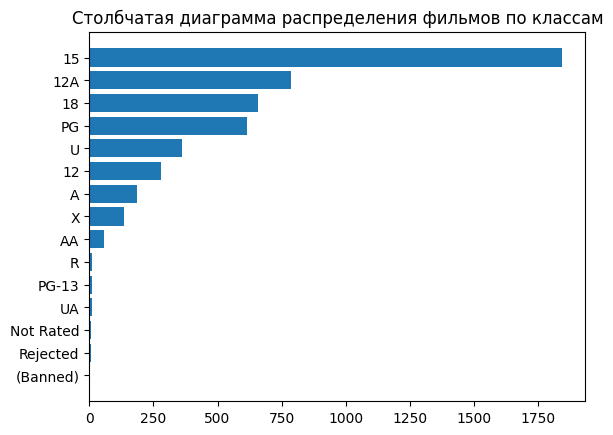

In [ ]:
plt.barh(certificate_counts.index, certificate_counts.values)
plt.title('Столбчатая диаграмма распределения фильмов по классам')
plt.show()

Выделим топ-5 классов, по которым больше всего фильмов

In [ ]:
certificate_counts_top_5 = dataset['certificate'].value_counts()[:5]

Круговая диаграмма

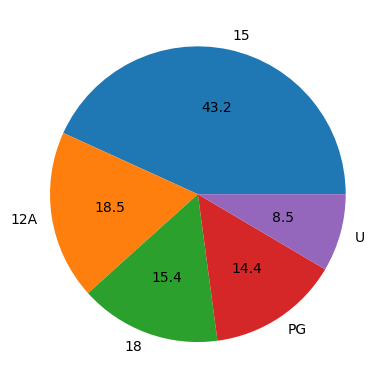

In [ ]:
plt.pie(certificate_counts_top_5.values, labels = certificate_counts_top_5.index,autopct='%.1f')
plt.show()

**Выводы:**

1. В наборе данных присутствуют 15 уникальных значений признака certificate

2. top=15: Наиболее часто встречающейся классификацией является "15". Это значит, что большинство фильмов в наборе данных имеет возрастное ограничение: просмотр разрешен старше 15 лет.

3.
    
    **Наиболее встречаемые**:
  Классификация 15 является наиболее распространенной.
  Следующие по популярности: 12A, 18, PG и U. Они входят в пятерку наиболее часто встречаемых

    **Наименее встречаемые**:
  R, PG-13, UA, Not Rated, Rejected и (Banned) встречаются очень редко.

4. **Столбчатая диаграмма** показывает распределение фильмов по классификационным категориям (возрастное ограничение 15 существенно превосходит все остальные по частоте встречаемости, что мы и определили с помощью метода describe()).

  **Круговая диаграмма** показывает процентное соотношение фильмов для 5 самых популярных категорий.

### *6.2. rating*

In [ ]:
dataset['rating'].describe()

,rating
count,4970.000000
mean,6.694004
std,0.967945
min,1.500000
25%,6.100000
50%,6.800000
75%,7.400000
max,9.300000


In [ ]:
dataset['rating'].unique()

array([9.3, 9.2, 9. , 8.9, 8.8, 8.7, 8.6, 8.5, 8.4, 8.3, 8.2, 8.1, 8. ,
       7.9, 7.8, 7.7, 7.6, 7.5, 7.4, 7.3, 7.2, 7.1, 7. , 6.9, 6.8, 6.7,
       6.6, 6.5, 6.4, 6.3, 6.2, 6.1, 6. , 5.9, 5.8, 5.7, 5.6, 5.5, 5.4,
       5.3, 5.2, 5.1, 5. , 4.9, 4.8, 4.7, 4.6, 4.5, 4.4, 4.3, 4.2, 4.1,
       4. , 3.9, 3.8, 3.7, 3.6, 3.5, 3.4, 3.3, 3.1, 3. , 2.9, 2.8, 2.6,
       2.5, 2.4, 2.3, 2.2, 2.1, 1.9, 1.5])

In [ ]:
dataset['rating'].value_counts()

,count
rating,
6.7,221
6.4,218
6.6,209
7.2,207
7.0,206
...,...
2.1,1
9.3,1
2.3,1


In [ ]:
rating_counts = dataset['rating'].value_counts().sort_values(ascending=True)

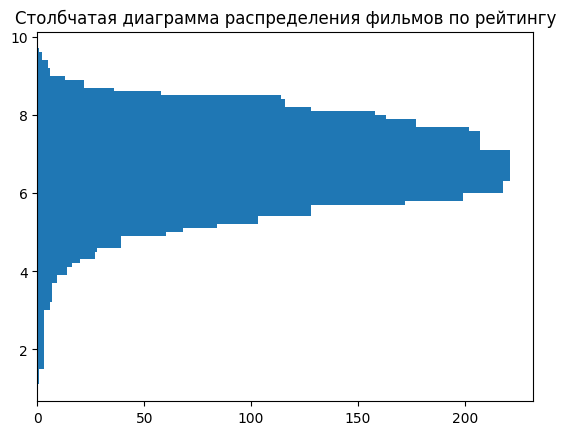

In [ ]:
plt.barh(rating_counts.index, rating_counts.values)
plt.title('Столбчатая диаграмма распределения фильмов по рейтингу')
plt.show()

In [ ]:
rating_counts_top_5 = dataset['rating'].value_counts().head(5)
rating_counts_top_5

,count
rating,
6.7,221
6.4,218
6.6,209
7.2,207
7.0,206


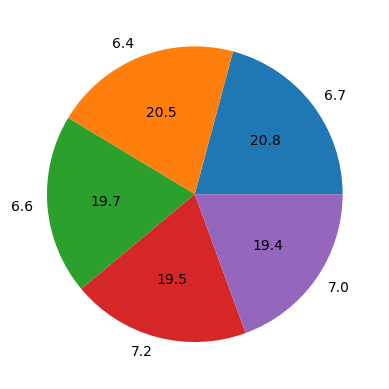

In [ ]:
plt.pie(rating_counts_top_5.values, labels = rating_counts_top_5.index,autopct='%.1f')
plt.show()

Большая часть фильмов с рейтингом в пределах от 6.4 до 7.2

### *6.3. director*

In [ ]:
dataset['director'].describe()

,director
count,4970
unique,1954
top,Woody Allen
freq,38


In [ ]:
director_counts_top_5 = dataset['director'].value_counts()[:5]

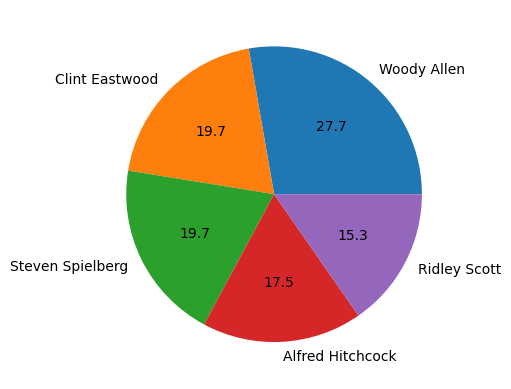

In [ ]:
plt.pie(director_counts_top_5.values, labels = director_counts_top_5.index,autopct='%.1f')
plt.show()

Здесь категориальные данные, но уникальных значений очень много. Выведем на круговой диаграмме процентное соотношение фильмов для 5 самых популярных режиссеров

## 7. Анализ взаимосвязи двух количественных признаков

### *7.1. runtime_clear - gross_earn_clear*

In [ ]:
import seaborn as sns

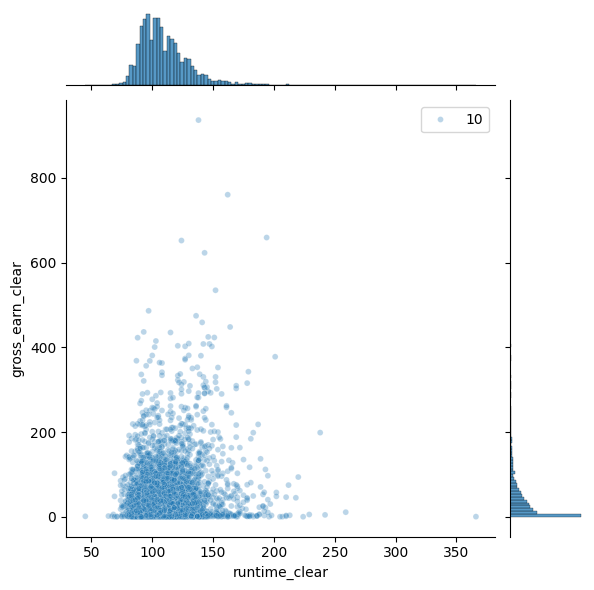

In [ ]:
sns.jointplot(x=dataset["runtime_clear"], y=dataset["gross_earn_clear"],size=10, alpha=0.3)
plt.show()

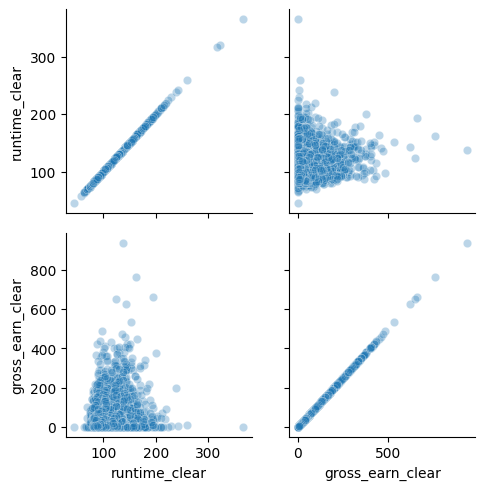

In [ ]:
columns = ['runtime_clear', 'gross_earn_clear']
g=sns.PairGrid(dataset[columns])
g.map(sns.scatterplot, alpha=0.3)

In [ ]:
new_dataset = dataset.copy()
for col in columns:
  limiter = new_dataset[col].quantile(0.99)
  new_dataset = new_dataset[new_dataset[col]<=limiter]

Построим диаграммы рассеяния

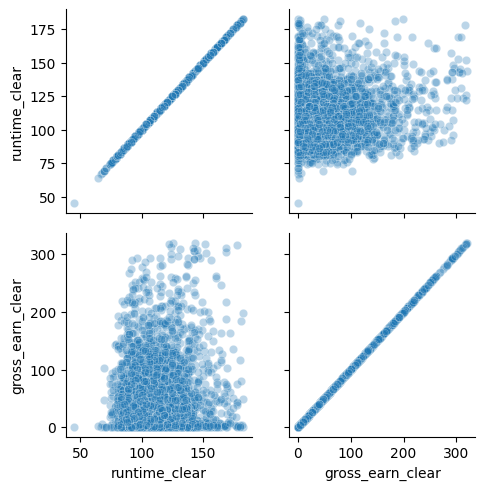

In [ ]:
g = sns.PairGrid(new_dataset[columns])
g.map(sns.scatterplot, alpha=0.3)

**Выводы:**

Какой-то четкой закономерности не прослеживается, то есть нет линейной зависимости дохода от продолжительности фильма. Сначала, при увеличении продолжительности фильма, наблюдается рост дохода, но при достижении продолжительности приблизительно 90 минут, рост дохода замедляется, и разброс данных увеличивается. Также на первой диаграмме рассеяния мы видим небольшое количество выбросов.

## 8. Анализ взаимосвязи двух категориальных признаков

### *8.1. director - certificate*

In [ ]:
directors = dataset['director'].unique()
len(directors)

1954

In [ ]:
dataset['director'].value_counts()

,count
director,
Woody Allen,38
Clint Eastwood,27
Steven Spielberg,27
Alfred Hitchcock,24
Ridley Scott,21
...,...
Sebastian Schipper,1
Jerry Zaks,1
Kinji Fukasaku,1


Определим топ-5 кинорежиссеров

In [ ]:
directors_top_5 = dataset['director'].value_counts()[:5].index
directors_top_5

Index(['Woody Allen', 'Clint Eastwood', 'Steven Spielberg', 'Alfred Hitchcock',
       'Ridley Scott'],
      dtype='object', name='director')

In [ ]:
labels = dataset['certificate'].unique()
colors = dict(zip(labels, plt.cm.tab20.colors[:len(labels)]))
colors

{'15': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 '12A': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'X': (1.0, 0.4980392156862745, 0.054901960784313725),
 'U': (1.0, 0.7333333333333333, 0.47058823529411764),
 '18': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'PG': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 '12': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'A': (1.0, 0.596078431372549, 0.5882352941176471),
 'AA': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'R': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 'Not Rated': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'Rejected': (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 'UA': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'PG-13': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 '(Banned)': (0.4980392156862745, 0.4980392156862745, 0.49803

**Выводы:**

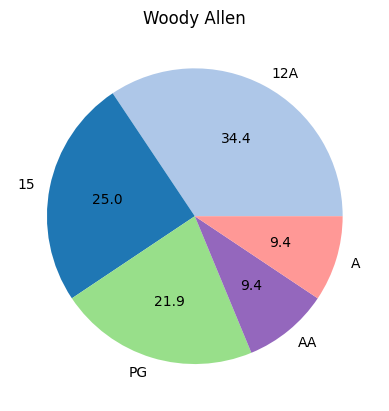

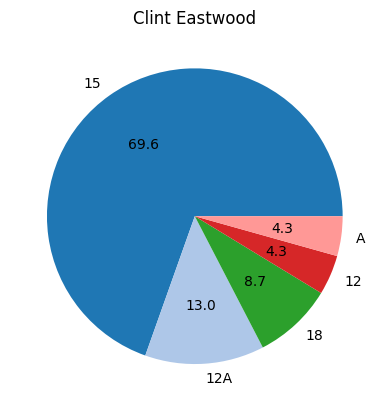

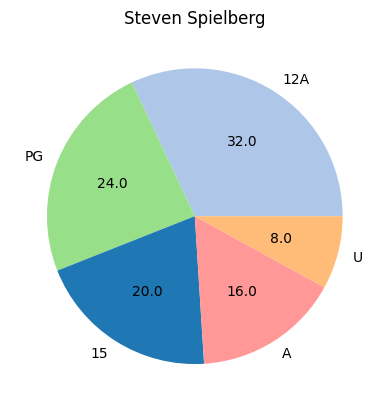

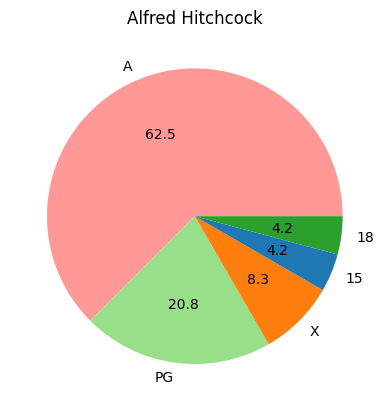

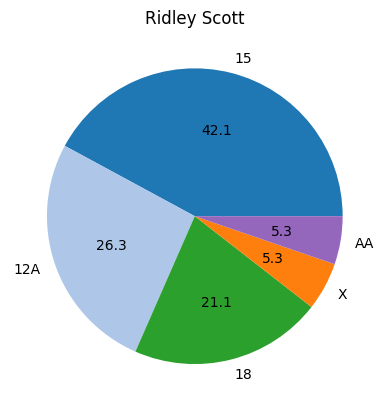

In [ ]:
for director in directors_top_5:
  df =dataset[dataset['director']==director]

  certificate_counts = df['certificate'].value_counts()[:5]
  labels = certificate_counts.index

  plt.title(director)
  plt.pie(certificate_counts.values, labels = labels, colors = [colors[key] for key in labels],autopct='%.1f')
  plt.show()

**1.Взаимосвязь**:

Круговые диаграммы показывают, что взаимосвязь между режиссером и классификацией фильмов есть. Распределение классификаций фильмов заметно различается для режиссеров и не является однородным. Разным режиссерам свойственны разные классификации. Различие в распределении категорий говорит о том, что режиссеры имеют разные стили и целевую аудиторию.

2.

**Аллен,Спилберг** делают фильмы для разных возрастных категорий (преобладают 12A, но естьи 15, PG, A). Оба режиссера создают контент, который может быть интересен как молодежи, так и взрослой аудитории.

Фильмы **Иствуда** в основном, ориентированы уже на более взрослую (категория 15 преобладает), но есть и 12, 12А.

Распределение категорий **Хичкока, Скотта** говорит о том, что они ориентируется на взрослую аудиторию (преобладают 15,A, также есть 18 и Х).

В перспективе более широкая аудитория может привести к большему количеству зрителей и, соответственно, большей прибыли.

## 9. Анализ взаимосвязи количественного и категориального признаков

### *9.1. certificate - gross_earn_clear*

In [ ]:
dataset.groupby('certificate')["gross_earn_clear"].median()

,gross_earn_clear
certificate,
(Banned),NaN
12,41.580
12A,42.650
15,18.840
18,14.945
A,16.140
AA,27.620
Not Rated,0.060
PG,44.340


In [ ]:
ban=dataset[dataset['certificate']=='(Banned)']
ban

,poster,title,certificate,runtime,genre,rating,about,director,stars,votes,gross_earn,runtime_clear,gross_earn_clear
2329,https://m.media-amazon.com/images/S/sash/4Fyxw...,Zombie Flesh Eaters,(Banned),91 min,Horror,6.8,Strangers searching for a young woman's missin...,Lucio Fulci,"('Tisa Farrow',), ('Ian McCulloch',), ('Richar...","28,020",NaN,91,NaN


Оценим описательные статистики доходов с фильмов в разрезе классов фильмов

In [ ]:
dataset.groupby('certificate')["gross_earn_clear"].describe()

,count,mean,std,min,25%,50%,75%,max
certificate,,,,,,,,
(Banned),0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,269.0,60.113048,66.805332,0.04,20.5500,41.580,72.220,659.33
12A,757.0,77.310925,100.261041,0.00,15.2700,42.650,95.000,936.66
15,1719.0,33.451798,42.503809,0.00,3.6100,18.840,45.870,363.07
18,600.0,26.607200,34.639021,0.00,2.5375,14.945,36.875,370.78
A,126.0,37.906190,50.157244,0.01,3.3925,16.140,51.245,260.00
AA,52.0,38.855769,37.479422,0.02,7.2700,27.620,57.635,139.88
Not Rated,5.0,3.830000,8.231376,0.01,0.0200,0.060,0.510,18.55
PG,581.0,64.011360,66.772893,0.01,18.6000,44.340,81.060,402.45


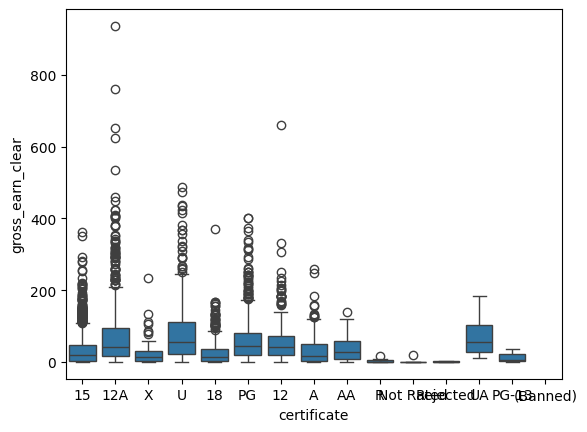

In [ ]:
sns.boxplot(x='certificate', y="gross_earn_clear", data=dataset)
plt.show()

Диаграмма получилась малоинформативна в связи с наличием выбросов, а также ее нагруженностью по количеству значений классов.

In [ ]:
dataset['certificate'].value_counts()

,count
certificate,
15,1843
12A,788
18,659
PG,614
U,362
12,278
A,186
X,134
AA,59


По итогу оценки видно, что крупных классов - 8, поэтому ограничим диаграмму топ-8 классов.

In [ ]:
certificate_list =dataset['certificate'].value_counts()[:8].index
certificate_list

Index(['15', '12A', '18', 'PG', 'U', '12', 'A', 'X'], dtype='object', name='certificate')

In [ ]:
dataset_certificate_top_8 = dataset[dataset['certificate'].isin(certificate_list)]
dataset_certificate_top_8.shape

(4864, 13)

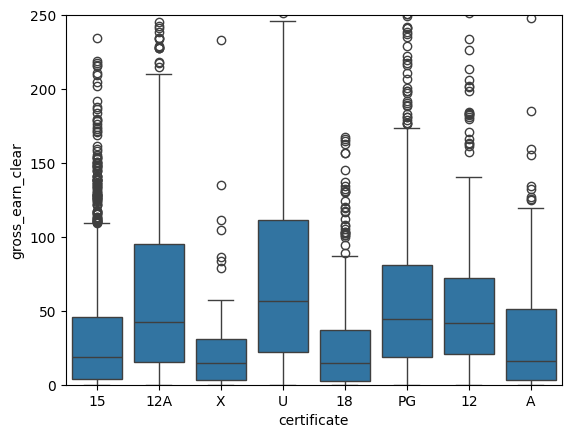

In [ ]:
sns.boxplot(x='certificate', y="gross_earn_clear", data=dataset_certificate_top_8)
plt.axis(ymin=0, ymax=250)
plt.show()

**Выводы:**

1. На диаграмме видна взаимосвязь между признаками "certificate" и "gross_earn_clear".
 Некоторые категории фильмов имеют похожее распределение дохода: категории 15, X, 18 и A имеют более низкие медианы более низкие диапазоны дохода по сравнению с категориями U, 12А, PG и 12.

 2.

  15: Имеет медианный доход около 20, низкий диапазон и большое количество выбросов;
  
  12A: Распределение немного шире, чем у 15, медиана - 30-40, также наблюдаются выбросы;
  
  X: Медиана около 20, и самый маленький разброс значений;
  
  U: Имеет наибольший доход, с медианой около 60-70. Разброс дохода широкий;
  
  18: Медиана также около 20, имеет большое количество выбросов
  
  PG: Медиана около 40-45 и широкий разброс значений, с большим количеством выбросов
  
  12: Медиана около 40, и широкий разброс значений, но не такой большой, как у U и 12А.
  
  A: Медиану около 20, небольшой разброс значений и небольшое количество выбросов.

**Общие выводы**:

Категория фильма влияет на его коммерческий успех.
Категория U (для любой аудитории),12А, PG и 12 имеют наибольшие медианные значения и разброс дохода, а категории 15, X, 18 и A демонстрируют низкие медианы и диапазоны.
Фильмы с меньшим ограничением по возрасту имеют потенциал привлечь более широкую аудиторию -> они охватывают более широкую аудиторию и имеют больший шанс на высокий доход. А фильмы, предназначенные для узкой аудитории, могут быть успешными, но в общем случае могут не приносить высоких доходов.

## 10. Общий вывод

 Итоговый вывод по проведенному разведочному анализу доходов

**Итоговый вывод из разведочного анализа**:

Рынок кинопроката характеризуется неравномерным распределением доходов. Большинство фильмов имеют относительно низкие или средние сборы (от 8 до 122) и только небольшое количество фильмов имеет очень высокие (блокбастеры). Это видно как на гистограмме, так и на box plot.

Прямой линейной взаимосвязи между продолжительностью фильма и его доходом нет (90-120 мин. - стандартная продолжительность)

Распределение классификаций фильмов заметно различается для режиссеров. Это указывает на наличие разных стилей и целевых аудиторий у разных режиссеров.

Фильмы с более низким возрастным ограничением потенциально привлекают более широкую аудиторию, что повышает их шансы на коммерческий успех.

Категория 15 встречается чаще всего, но не является наиболее прибыльной.

Из рассмотренных признаков **доход фильма зависит от**:


1. Класса фильма по рейтингу (BBFC): фильмы с более низкими возрастными ограничениями (U, 12A, PG и 12) имеют больший потенциал для высоких доходов из-за более широкой аудитории;
2. Режиссера: стиль режиссера, его аудитория влияют на распределение категорий его фильмов, а следовательно, и на их доход;
3. Продолжительности: связь не прямая, может играть роль, но не является определяющим фактором.

Для уточнения взаимосвязей и получения более точных выводов нужно провести анализ других признаков